# 07. Permutation Importance and Model Reliance

The previous notebook studied global response plots: PDP, ICE, and ALE. Those tools ask how a fitted prediction function changes as a feature value is varied.

This notebook studies a different explanation question:

> How much does the model's performance deteriorate when a feature's information is disrupted?

That question leads to **permutation importance** and the broader idea of **model reliance**. The method is appealing because it is model-agnostic: it can be applied to logistic regression, random forests, gradient boosting, neural networks, or any fitted prediction system. But the interpretation is subtle. A feature can look unimportant because another correlated feature carries similar information. A feature can look important because it is a proxy. A feature can be important for prediction without being a good intervention target.

The decision-science framing is therefore: permutation importance is a diagnostic for **predictive reliance**, not a ranking of causal levers or business value.


## Learning Objectives

By the end of this notebook, you should be able to:

1. Define permutation importance as a change in held-out performance after feature disruption.
2. Distinguish score-drop importance from loss-ratio model reliance.
3. Compute repeated permutation importance from scratch.
4. Explain why correlated features can split, mask, or transfer importance.
5. Use grouped permutation importance when a set of features represents one operational construct.
6. Compare reliance rankings across different model classes and metrics.
7. Interpret negative or near-zero importances correctly.
8. Explain why feature importance is not causality, actionability, fairness, or business value.


In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:0.3f}')
pd.set_option('display.max_columns', 90)
pd.set_option('display.max_colwidth', 260)
np.random.seed(2031)

TARGET = 'renewal_risk'
FEATURES = [
    'active_users',
    'usage_depth',
    'training_completion',
    'product_adoption',
    'support_tickets_30d',
    'recent_incidents_90d',
    'billing_delay_days',
    'contract_value_log',
    'executive_sponsor',
    'enterprise_segment',
    'international_region',
    'pooled_support_motion',
    'random_noise_feature',
]

FEATURE_LABELS = {
    'active_users': 'Active users',
    'usage_depth': 'Usage depth',
    'training_completion': 'Training completion',
    'product_adoption': 'Product adoption',
    'support_tickets_30d': 'Support tickets in last 30 days',
    'recent_incidents_90d': 'Recent incidents in last 90 days',
    'billing_delay_days': 'Billing delay days',
    'contract_value_log': 'Log contract value',
    'executive_sponsor': 'Executive sponsor present',
    'enterprise_segment': 'Enterprise segment',
    'international_region': 'International region',
    'pooled_support_motion': 'Pooled support motion',
    'random_noise_feature': 'Random noise feature',
}


## 1. Model Reliance As A Performance Perturbation

Let $D=\{(x_i,y_i)\}_{i=1}^n$ be a held-out dataset, and let $\hat f$ be a fitted model. Let $L(\hat f;D)$ denote a loss where smaller is better, such as log loss or Brier score.

To measure reliance on feature $j$, create a perturbed dataset $D_j^{\pi}$ by randomly permuting feature $j$ across rows while leaving all other columns and labels fixed. This destroys the row-level association between $x_j$ and $y$, while preserving the marginal distribution of $x_j$.

A loss-difference importance is

$$
I_j^{diff}
= L(\hat f;D_j^{\pi}) - L(\hat f;D).
$$

A loss-ratio version, often called model reliance, is

$$
MR_j
= \frac{L(\hat f;D_j^{\pi})}{L(\hat f;D)}.
$$

For performance scores where larger is better, such as AUC or average precision, we usually report a score drop:

$$
I_j^{score}
= S(\hat f;D) - S(\hat f;D_j^{\pi}).
$$

The interpretation is direct: if disrupting a feature damages held-out performance, the fitted model relied on that feature for prediction. If performance barely changes, the model did not rely strongly on that feature by this metric, on this dataset, for this fitted model.


## 2. Synthetic Decision Case: Renewal-Risk Triage

We use a customer-success renewal-risk setting. A team must decide which accounts deserve proactive retention review. The target is `renewal_risk`.

The synthetic data are built to expose common importance pitfalls:

| Data design choice | Why it matters for permutation importance |
|---|---|
| `training_completion` and `product_adoption` are correlated | Importance can be split across redundant maturity signals |
| `support_tickets_30d` and `recent_incidents_90d` are correlated | Disrupting one burden variable may leave the other as a substitute |
| A random noise feature is included | A sanity check: importance should be near zero |
| Several model classes are fitted | Reliance is model-specific, not an intrinsic property of the dataset |
| Grouped operational constructs are defined | Teams often act on constructs such as maturity or support burden, not one raw column |


In [2]:
# Section focus: 2. Synthetic Decision Case: Renewal-Risk Triage.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-np.clip(x, -35, 35)))


def make_reliance_dataset(n=6200, seed=2031):
    """Construct the reliance dataset helper used in the 07. Permutation Importance and Model Reliance workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    segment = rng.choice(['growth', 'mid-market', 'enterprise'], size=n, p=[0.46, 0.35, 0.19])
    region = rng.choice(['North', 'South', 'West', 'International'], size=n, p=[0.31, 0.23, 0.29, 0.17])
    support_motion = rng.choice(['reactive', 'pooled', 'dedicated'], size=n, p=[0.48, 0.35, 0.17])

    enterprise_segment = (segment == 'enterprise').astype(int)
    international_region = (region == 'International').astype(int)
    pooled_support_motion = (support_motion == 'pooled').astype(int)
    dedicated_support_motion = (support_motion == 'dedicated').astype(int)

    account_maturity = np.clip(
        rng.beta(3.0, 2.5, n)
        + 0.10 * enterprise_segment
        + 0.07 * dedicated_support_motion
        - 0.06 * pooled_support_motion,
        0.02,
        0.98,
    )

    contract_value_log = np.clip(
        rng.normal(9.6 + 0.85 * enterprise_segment + 0.32 * (segment == 'mid-market'), 0.45, n),
        8.2,
        12.0,
    )

    executive_sponsor = rng.binomial(
        1,
        np.clip(0.16 + 0.25 * (segment == 'mid-market') + 0.50 * enterprise_segment + 0.20 * account_maturity, 0.03, 0.94),
        size=n,
    )

    training_completion = np.clip(
        0.18
        + 0.62 * account_maturity
        + 0.13 * executive_sponsor
        - 0.07 * pooled_support_motion
        - 0.05 * international_region
        + rng.normal(0, 0.10, n),
        0.02,
        0.99,
    )

    product_adoption = np.clip(
        0.12
        + 0.68 * training_completion
        + 0.10 * executive_sponsor
        + 0.04 * dedicated_support_motion
        - 0.06 * pooled_support_motion
        + rng.normal(0, 0.08, n),
        0.02,
        0.99,
    )

    active_users = np.clip(
        rng.normal(58 + 95 * product_adoption + 38 * enterprise_segment + 18 * executive_sponsor, 22, n),
        1,
        260,
    )

    usage_depth = np.clip(
        0.18
        + 0.48 * product_adoption
        + 0.16 * account_maturity
        - 0.04 * pooled_support_motion
        + rng.normal(0, 0.09, n),
        0.02,
        0.98,
    )

    support_tickets_30d = rng.poisson(
        np.clip(1.0 + 1.15 * enterprise_segment + 0.90 * pooled_support_motion + 0.42 * (1 - product_adoption) + 0.15 * contract_value_log, 0.1, None)
    )

    recent_incidents_90d = rng.poisson(
        np.clip(0.05 + 0.23 * support_tickets_30d + 0.50 * (1 - usage_depth) + 0.12 * international_region, 0.02, None)
    )

    billing_delay_days = np.clip(
        rng.gamma(shape=1.7, scale=1.9, size=n) + 1.2 * international_region + 0.4 * (segment == 'growth'),
        0,
        35,
    )

    random_noise_feature = rng.normal(0, 1, n)

    low_maturity = ((training_completion < 0.48) & (product_adoption < 0.42)).astype(int)
    support_burden = ((support_tickets_30d >= 5) & (recent_incidents_90d >= 2)).astype(int)
    commercial_risk = ((billing_delay_days > 7.5) & (executive_sponsor == 0)).astype(int)

    logit = (
        -3.85
        - 0.0042 * active_users
        - 1.30 * usage_depth
        - 0.85 * training_completion
        - 1.15 * product_adoption
        + 0.18 * support_tickets_30d
        + 0.48 * recent_incidents_90d
        + 0.07 * billing_delay_days
        + 0.08 * contract_value_log
        - 0.48 * executive_sponsor
        + 0.22 * enterprise_segment
        + 0.26 * international_region
        + 0.28 * pooled_support_motion
        + 1.10 * low_maturity
        + 0.78 * support_burden
        + 0.52 * commercial_risk
    )

    renewal_risk = rng.binomial(1, sigmoid(logit), size=n)

    return pd.DataFrame(
        {
            'segment': segment,
            'region': region,
            'support_motion': support_motion,
            'account_maturity': account_maturity,
            'active_users': active_users,
            'usage_depth': usage_depth,
            'training_completion': training_completion,
            'product_adoption': product_adoption,
            'support_tickets_30d': support_tickets_30d,
            'recent_incidents_90d': recent_incidents_90d,
            'billing_delay_days': billing_delay_days,
            'contract_value_log': contract_value_log,
            'executive_sponsor': executive_sponsor,
            'enterprise_segment': enterprise_segment,
            'international_region': international_region,
            'pooled_support_motion': pooled_support_motion,
            'random_noise_feature': random_noise_feature,
            'low_maturity': low_maturity,
            'support_burden': support_burden,
            'commercial_risk': commercial_risk,
            'renewal_risk': renewal_risk,
        }
    )


df = make_reliance_dataset()
train_df, test_df = train_test_split(df, test_size=0.30, stratify=df[TARGET], random_state=2031)

X_train = train_df[FEATURES].reset_index(drop=True)
y_train = train_df[TARGET].reset_index(drop=True)
X_test = test_df[FEATURES].reset_index(drop=True)
y_test = test_df[TARGET].reset_index(drop=True)

summary = pd.DataFrame(
    [
        {'quantity': 'Rows', 'value': len(df)},
        {'quantity': 'Train rows', 'value': len(train_df)},
        {'quantity': 'Test rows', 'value': len(test_df)},
        {'quantity': 'Renewal-risk rate', 'value': df[TARGET].mean()},
        {'quantity': 'Correlation: training and adoption', 'value': df[['training_completion', 'product_adoption']].corr().iloc[0, 1]},
        {'quantity': 'Correlation: tickets and incidents', 'value': df[['support_tickets_30d', 'recent_incidents_90d']].corr().iloc[0, 1]},
        {'quantity': 'Low-maturity segment share', 'value': df['low_maturity'].mean()},
        {'quantity': 'Support-burden segment share', 'value': df['support_burden'].mean()},
    ]
)

segment_summary = (
    df.groupby('support_motion', as_index=False)
    .agg(
        rows=(TARGET, 'size'),
        renewal_risk_rate=(TARGET, 'mean'),
        mean_training=('training_completion', 'mean'),
        mean_adoption=('product_adoption', 'mean'),
        mean_tickets=('support_tickets_30d', 'mean'),
        mean_incidents=('recent_incidents_90d', 'mean'),
    )
    .sort_values('renewal_risk_rate', ascending=False)
)

smart_display(summary.round(3))
smart_display(segment_summary.round(3))
smart_display(df[FEATURES + [TARGET]].head(6).round(3))


,quantity,value
0,Rows,6200.000000
1,Train rows,4340.000000
2,Test rows,1860.000000
3,Renewal-risk rate,0.078000
4,Correlation: training and adoption,0.860000
5,Correlation: tickets and incidents,0.383000
6,Low-maturity segment share,0.251000
7,Support-burden segment share,0.105000


,support_motion,rows,renewal_risk_rate,mean_training,mean_adoption,mean_tickets,mean_incidents
1,pooled,2246,0.147,0.470,0.425,3.925,1.244
2,reactive,2838,0.045,0.583,0.564,2.881,0.943
0,dedicated,1116,0.021,0.623,0.632,2.746,0.914


,active_users,usage_depth,training_completion,product_adoption,support_tickets_30d,recent_incidents_90d,billing_delay_days,contract_value_log,executive_sponsor,enterprise_segment,international_region,pooled_support_motion,random_noise_feature,renewal_risk
0,97.406,0.395,0.735,0.504,1,1,1.522,9.880,0,0,0,0,0.772,0
1,93.215,0.572,0.724,0.573,2,0,8.099,9.694,0,0,0,0,0.299,0
2,188.983,0.564,0.606,0.603,6,0,2.849,10.186,0,1,0,0,1.269,0
3,68.932,0.371,0.587,0.325,1,0,2.904,9.814,0,0,0,1,1.980,0
4,161.398,0.615,0.506,0.616,3,2,5.262,10.015,1,0,0,0,-0.680,0
5,78.857,0.276,0.446,0.415,0,0,3.966,9.713,0,0,0,0,0.695,0


Read Synthetic Decision Case: Renewal-Risk Triage as a communication test. A reportable explanation should be clear, checkable, and reasonably stable.


### Discussion of The Data Design

The two correlations in the summary table are the important part. Product adoption and training completion overlap as maturity signals. Tickets and incidents overlap as burden signals. A permutation importance calculation on one raw column can therefore understate the importance of the underlying construct.

This is a common industry problem. Business concepts rarely map one-to-one onto individual columns. They often appear as clusters of correlated operational measurements.

The data are also designed to separate column importance from concept importance. A single business construct can be spread across several fields. Adoption may appear as usage depth, training completion, and feature breadth. Support burden may appear as tickets, incidents, and escalation history. If we permute one column at a time, the model may recover the same construct from a correlated neighbor.

That is the reason this notebook compares ordinary permutation importance with grouped or conditional views. The experiment asks whether the model relies on business constructs in a way that stakeholders can inspect and trust, beyond ranking variables.


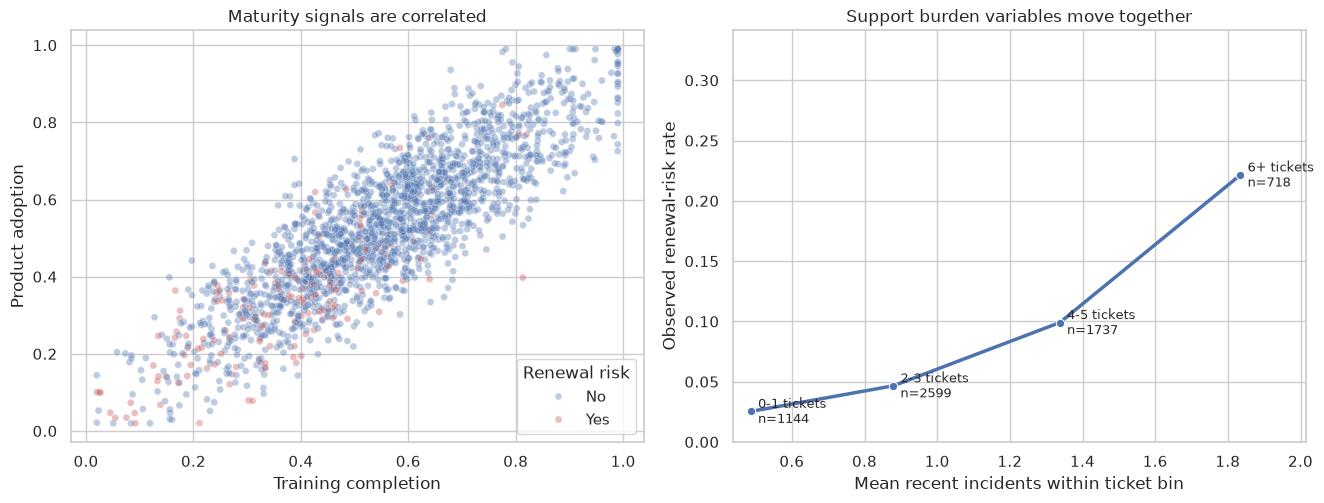

In [3]:
# Section focus: Discussion of The Data Design.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

plot_sample = df.sample(2000, random_state=2031)
sns.scatterplot(
    data=plot_sample,
    x='training_completion',
    y='product_adoption',
    hue=TARGET,
    palette={0: '#4c72b0', 1: '#c44e52'},
    alpha=0.36,
    s=25,
    ax=axes[0],
)
axes[0].set_title('Maturity signals are correlated')
axes[0].set_xlabel('Training completion')
axes[0].set_ylabel('Product adoption')
handles, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=['No', 'Yes'], title='Renewal risk', loc='lower right')

burden = (
    df.assign(ticket_bin=pd.cut(df['support_tickets_30d'], bins=[-0.1, 1, 3, 5, 12], labels=['0-1', '2-3', '4-5', '6+']))
    .groupby('ticket_bin', observed=True)
    .agg(mean_incidents=('recent_incidents_90d', 'mean'), renewal_risk_rate=(TARGET, 'mean'), rows=(TARGET, 'size'))
    .reset_index()
)
sns.lineplot(data=burden, x='mean_incidents', y='renewal_risk_rate', marker='o', linewidth=2.5, ax=axes[1])
for _, row in burden.iterrows():
    axes[1].text(row['mean_incidents'] + 0.02, row['renewal_risk_rate'], f"{row['ticket_bin']} tickets\nn={int(row['rows'])}", fontsize=9, va='center')
axes[1].set_title('Support burden variables move together')
axes[1].set_xlabel('Mean recent incidents within ticket bin')
axes[1].set_ylabel('Observed renewal-risk rate')
axes[1].set_xlim(burden['mean_incidents'].min() - 0.05, burden['mean_incidents'].max() + 0.18)
axes[1].set_ylim(0, min(0.7, burden['renewal_risk_rate'].max() + 0.12))

plt.tight_layout()
plt.show()


Discussion of The Data Design should make the model story easier to inspect instead of merely more polished.


## 3. Fit Models Whose Reliance We Can Compare

Model reliance is not a property of a feature alone. It is a property of a fitted model, a metric, and a data distribution.

We fit three models:

| Model | Why include it? |
|---|---|
| Logistic regression | A transparent baseline with mostly additive structure |
| Random forest | A nonlinear ensemble with feature subsampling and interaction capacity |
| Histogram gradient boosting | A strong nonlinear model with staged tree additions |

If the same feature receives different reliance scores across models, that is not necessarily a contradiction. It may mean the models learned different prediction strategies.


In [4]:
# Section focus: 3. Fit Models Whose Reliance We Can Compare.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

scaler = ColumnTransformer(
    [('scale', StandardScaler(), FEATURES)],
    remainder='drop',
)

logistic_model = Pipeline(
    steps=[
        ('scale', scaler),
        ('model', LogisticRegression(max_iter=2000, C=0.65, solver='lbfgs')),
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=220,
    max_depth=8,
    min_samples_leaf=35,
    random_state=2031,
    n_jobs=-1,
)

gbm_model = HistGradientBoostingClassifier(
    max_iter=220,
    learning_rate=0.045,
    max_leaf_nodes=24,
    l2_regularization=0.025,
    min_samples_leaf=35,
    random_state=2031,
)

models = {
    'Logistic regression': logistic_model,
    'Random forest': rf_model,
    'Gradient boosting': gbm_model,
}

for model in models.values():
    model.fit(X_train, y_train)


def predict_risk(model, X):
    """Carry out the predict risk step used in the 07. Permutation Importance and Model Reliance workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the predict risk calculation.
    """
    return model.predict_proba(X)[:, 1]


def model_metrics(model, X, y):
    """Carry out the model metrics step used in the 07. Permutation Importance and Model Reliance workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    y : object
        Observed target values used for fitting or evaluation.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    pred = predict_risk(model, X)
    return {
        'roc_auc': roc_auc_score(y, pred),
        'average_precision': average_precision_score(y, pred),
        'brier_score': brier_score_loss(y, pred),
        'log_loss': log_loss(y, pred),
        'mean_predicted_risk': pred.mean(),
    }

metric_table = pd.DataFrame(
    [{'model': name, **model_metrics(model, X_test, y_test)} for name, model in models.items()]
).sort_values('roc_auc', ascending=False)
smart_display(metric_table.round(3))


,model,roc_auc,average_precision,brier_score,log_loss,mean_predicted_risk
0,Logistic regression,0.850,0.427,0.057,0.205,0.076
1,Random forest,0.829,0.367,0.060,0.215,0.074
2,Gradient boosting,0.807,0.341,0.064,0.251,0.064


This result is an interpretation diagnostic. For Fit Models Whose Reliance We Can Compare, look at whether the explanation is stable, plausible, and useful for stakeholder review. The useful version of a fragile story is one that clearly states its boundaries.


### Discussion of The Baseline Models

The models have similar but not identical performance. That is ideal for this lecture. If all models performed badly, feature reliance would not be very meaningful. If one model dominated completely, comparing reliance across models would be less interesting.

The baseline performance table is also a reminder: importance should be computed on held-out data. If importance is computed on the training set, it can reward features that helped overfit rather than features that support generalization.


## 4. Repeated Permutation Importance From Scratch

One permutation can be noisy. A better diagnostic repeats the shuffle multiple times and reports a distribution.

For a score where larger is better, such as ROC AUC, we compute

$$
\Delta_j^{(b)} = S(\hat f;D) - S(\hat f;D_{j}^{\pi_b}),
$$

where $b$ indexes permutation repetitions. The mean of $\Delta_j^{(b)}$ is the average score deterioration, and the spread shows Monte Carlo uncertainty from the random permutation.

A feature can have negative permutation importance in a finite sample. That means the shuffled version performed slightly better than the original on that repetition. Small negative values are usually noise, not evidence that the feature is actively harmful.


In [5]:
# Section focus: 4. Repeated Permutation Importance From Scratch.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def evaluate_score(model, X, y, metric='roc_auc'):
    """Evaluate score for the 07. Permutation Importance and Model Reliance decision workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    y : object
        Observed target values used for fitting or evaluation.
    metric : object
        Metric name or metric value used to score model or decision behavior.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the score calculation.
    """
    pred = predict_risk(model, X)
    if metric == 'roc_auc':
        return roc_auc_score(y, pred)
    if metric == 'average_precision':
        return average_precision_score(y, pred)
    raise ValueError(f'Unsupported score metric: {metric}')


def evaluate_loss(model, X, y, metric='log_loss'):
    """Evaluate loss for the 07. Permutation Importance and Model Reliance decision workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    y : object
        Observed target values used for fitting or evaluation.
    metric : object
        Metric name or metric value used to score model or decision behavior.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the loss calculation.
    """
    pred = predict_risk(model, X)
    if metric == 'log_loss':
        return log_loss(y, pred)
    if metric == 'brier_score':
        return brier_score_loss(y, pred)
    raise ValueError(f'Unsupported loss metric: {metric}')


def repeated_permutation_importance_score(model, X, y, features, metric='roc_auc', n_repeats=35, seed=2031):
    """Carry out the repeated permutation importance score step used in the 07. Permutation Importance and Model Reliance workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    y : object
        Observed target values used for fitting or evaluation.
    features : object
        Feature column names or feature matrix used by the model.
    metric : object
        Metric name or metric value used to score model or decision behavior.
    n_repeats : object
        Count or size setting for the repeated permutation importance score calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    baseline = evaluate_score(model, X, y, metric=metric)
    rows = []
    X_base = X.reset_index(drop=True)

    for feature in features:
        for repeat in range(n_repeats):
            X_perm = X_base.copy()
            X_perm[feature] = rng.permutation(X_perm[feature].to_numpy())
            permuted_score = evaluate_score(model, X_perm, y, metric=metric)
            rows.append(
                {
                    'feature': feature,
                    'feature_label': FEATURE_LABELS[feature],
                    'repeat': repeat,
                    'metric': metric,
                    'baseline_score': baseline,
                    'permuted_score': permuted_score,
                    'score_drop': baseline - permuted_score,
                }
            )
    return pd.DataFrame(rows)


def summarize_score_importance(importance_df):
    """Summarize score importance for the 07. Permutation Importance and Model Reliance analysis.
    
    Parameters
    ----------
    importance_df : object
        Tabular data object used as the input or output of this workflow step.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the score importance calculation.
    """
    return (
        importance_df.groupby(['feature', 'feature_label'], as_index=False)
        .agg(
            mean_score_drop=('score_drop', 'mean'),
            sd_score_drop=('score_drop', 'std'),
            p05=('score_drop', lambda x: np.quantile(x, 0.05)),
            p95=('score_drop', lambda x: np.quantile(x, 0.95)),
            negative_share=('score_drop', lambda x: np.mean(np.asarray(x) < 0)),
        )
        .sort_values('mean_score_drop', ascending=False)
    )

importance_auc_gbm = repeated_permutation_importance_score(
    gbm_model,
    X_test,
    y_test,
    FEATURES,
    metric='roc_auc',
    n_repeats=28,
    seed=2031,
)
importance_auc_summary = summarize_score_importance(importance_auc_gbm)
smart_display(importance_auc_summary.round(4))


,feature,feature_label,mean_score_drop,sd_score_drop,p05,p95,negative_share
7,product_adoption,Product adoption,0.056200,0.012600,0.036500,0.073600,0.000000
9,recent_incidents_90d,Recent incidents in last 90 days,0.038400,0.005500,0.031000,0.046900,0.000000
10,support_tickets_30d,Support tickets in last 30 days,0.022400,0.007100,0.014300,0.031900,0.000000
11,training_completion,Training completion,0.020400,0.006600,0.012000,0.031300,0.000000
12,usage_depth,Usage depth,0.016400,0.007000,0.007400,0.028600,0.000000
6,pooled_support_motion,Pooled support motion,0.006200,0.003100,0.001400,0.011000,0.035700
1,billing_delay_days,Billing delay days,0.006000,0.004000,0.000500,0.011100,0.035700
4,executive_sponsor,Executive sponsor present,0.000300,0.001400,-0.001900,0.002700,0.464300
3,enterprise_segment,Enterprise segment,-0.000100,0.000400,-0.000600,0.000700,0.535700
5,international_region,International region,-0.000400,0.001400,-0.002900,0.001300,0.571400


This result is an interpretation diagnostic. For Repeated Permutation Importance From Scratch, look at whether the explanation is stable, plausible, and useful for stakeholder review. The analyst should report this as sensitivity in the explanation layer.


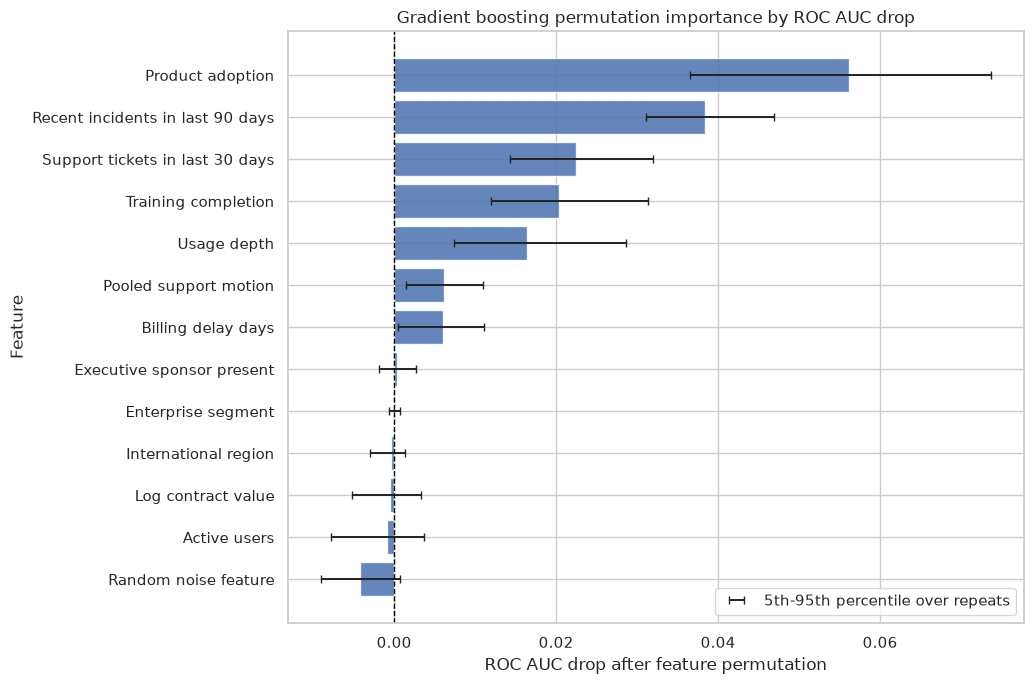

In [6]:
plot_importance = importance_auc_summary.sort_values('mean_score_drop', ascending=True).copy()

fig, ax = plt.subplots(figsize=(10.5, 7.0))
ax.barh(plot_importance['feature_label'], plot_importance['mean_score_drop'], color='#4c72b0', alpha=0.86)
ax.errorbar(
    x=plot_importance['mean_score_drop'],
    y=np.arange(len(plot_importance)),
    xerr=[plot_importance['mean_score_drop'] - plot_importance['p05'], plot_importance['p95'] - plot_importance['mean_score_drop']],
    fmt='none',
    ecolor='#222222',
    elinewidth=1.4,
    capsize=3,
    label='5th-95th percentile over repeats',
)
ax.axvline(0, color='black', linestyle='--', linewidth=1.0)
ax.set_title('Gradient boosting permutation importance by ROC AUC drop')
ax.set_xlabel('ROC AUC drop after feature permutation')
ax.set_ylabel('Feature')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


The explanation result should be compared with the decision story. In Repeated Permutation Importance From Scratch, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. In practice, a clearer explanation lowers review burden and makes the recommendation easier to defend.


### Discussion of Single-Feature Permutation Importance

The random noise feature should sit near zero. If it does not, something is wrong with the workflow or the sample is too small. Here it behaves as a sanity check.

The top features tell us which columns the gradient boosting model relied on for ranking renewal risk. They do not tell us which business levers are most valuable. For example, a support-burden feature can be important because it is an early warning sign, but reducing tickets may not itself remove the root cause of churn risk.


## 5. Metric Dependence: Importance For What Objective?

Permutation importance is tied to the evaluation metric. A feature can be important for ranking high-risk accounts but less important for calibrated probabilities, or vice versa.

We compare AUC-drop importance with average-precision-drop importance. AUC summarizes pairwise ranking over all thresholds. Average precision emphasizes ranking quality near the positive class, which can matter more in triage settings where only a fraction of accounts can be reviewed.


,feature,feature_label,auc_drop,average_precision_drop,rank_by_auc,rank_by_average_precision
0,product_adoption,Product adoption,0.056200,0.075800,1,2
1,recent_incidents_90d,Recent incidents in last 90 days,0.038400,0.119400,2,1
2,support_tickets_30d,Support tickets in last 30 days,0.022400,0.049500,3,3
3,training_completion,Training completion,0.020400,0.035700,4,4
4,usage_depth,Usage depth,0.016400,0.022100,5,5
5,pooled_support_motion,Pooled support motion,0.006200,0.006000,6,6
6,billing_delay_days,Billing delay days,0.006000,0.003000,7,7
7,executive_sponsor,Executive sponsor present,0.000300,-0.001000,8,10
8,enterprise_segment,Enterprise segment,-0.000100,0.000800,9,8
9,international_region,International region,-0.000400,-0.000600,10,9


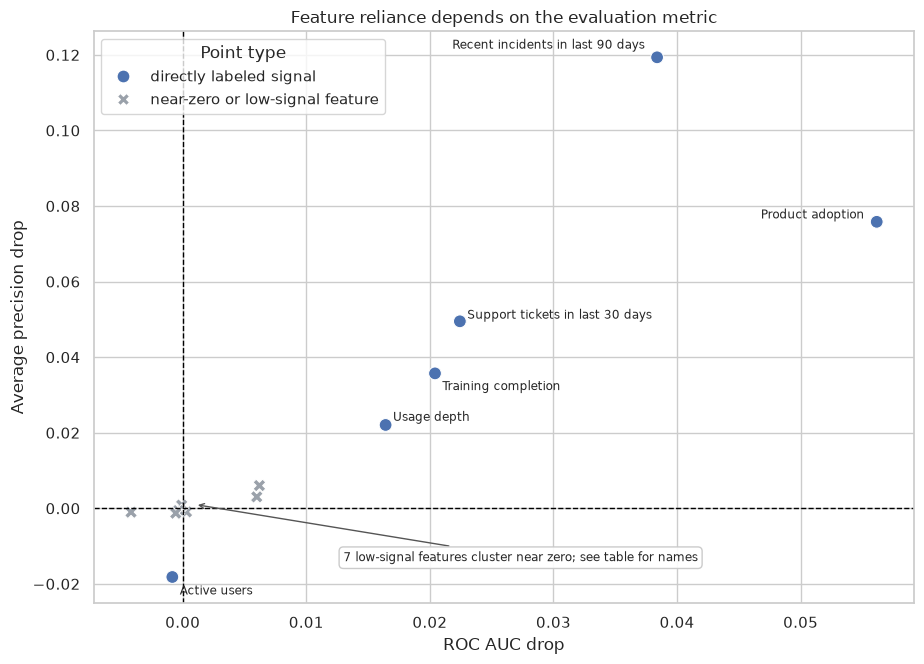

In [7]:
# Section focus: 5. Metric Dependence: Importance For What Objective?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

importance_ap_gbm = repeated_permutation_importance_score(
    gbm_model,
    X_test,
    y_test,
    FEATURES,
    metric='average_precision',
    n_repeats=28,
    seed=2032,
)
importance_ap_summary = summarize_score_importance(importance_ap_gbm)

metric_comparison = (
    importance_auc_summary[['feature', 'feature_label', 'mean_score_drop']]
    .rename(columns={'mean_score_drop': 'auc_drop'})
    .merge(
        importance_ap_summary[['feature', 'mean_score_drop']].rename(columns={'mean_score_drop': 'average_precision_drop'}),
        on='feature',
        how='left',
    )
)
metric_comparison['rank_by_auc'] = metric_comparison['auc_drop'].rank(ascending=False, method='min').astype(int)
metric_comparison['rank_by_average_precision'] = metric_comparison['average_precision_drop'].rank(ascending=False, method='min').astype(int)
metric_comparison = metric_comparison.sort_values('auc_drop', ascending=False)
smart_display(metric_comparison.round(4))

metric_plot = metric_comparison.copy()
label_features = {
    'product_adoption',
    'recent_incidents_90d',
    'support_tickets_30d',
    'training_completion',
    'usage_depth',
    'active_users',
}
metric_plot['display_group'] = np.where(
    metric_plot['feature'].isin(label_features),
    'directly labeled signal',
    'near-zero or low-signal feature',
)

fig, ax = plt.subplots(figsize=(9.4, 6.8))
sns.scatterplot(
    data=metric_plot,
    x='auc_drop',
    y='average_precision_drop',
    hue='display_group',
    style='display_group',
    s=85,
    palette=['#4c72b0', '#9aa1aa'],
    ax=ax,
)

label_offsets = {
    'product_adoption': (-0.0010, 0.0018, 'right'),
    'recent_incidents_90d': (-0.0010, 0.0032, 'right'),
    'support_tickets_30d': (0.0006, 0.0016, 'left'),
    'training_completion': (0.0006, -0.0035, 'left'),
    'usage_depth': (0.0006, 0.0020, 'left'),
    'active_users': (0.0006, -0.0038, 'left'),
}
for _, row in metric_plot.loc[metric_plot['feature'].isin(label_features)].iterrows():
    dx, dy, ha = label_offsets[row['feature']]
    ax.text(
        row['auc_drop'] + dx,
        row['average_precision_drop'] + dy,
        row['feature_label'],
        fontsize=8.8,
        ha=ha,
        va='center',
    )

low_signal_count = int((~metric_plot['feature'].isin(label_features)).sum())
ax.annotate(
    f'{low_signal_count} low-signal features cluster near zero; see table for names',
    xy=(0.001, 0.001),
    xytext=(0.013, -0.014),
    arrowprops={'arrowstyle': '->', 'color': '#555555', 'lw': 1.0},
    bbox={'boxstyle': 'round,pad=0.35', 'fc': 'white', 'ec': '#c7c7c7', 'alpha': 0.92},
    fontsize=8.8,
)
ax.axhline(0, color='black', linestyle='--', linewidth=1.0)
ax.axvline(0, color='black', linestyle='--', linewidth=1.0)
ax.set_title('Feature reliance depends on the evaluation metric')
ax.set_xlabel('ROC AUC drop')
ax.set_ylabel('Average precision drop')
ax.legend(title='Point type', loc='upper left')
plt.tight_layout()
plt.show()


This result is an interpretation diagnostic. For Metric Dependence: Importance For What Objective?, look at whether the explanation is stable, plausible, and useful for stakeholder review. The report should make clear when the explanation depends on the sample, baseline, or local neighborhood.


### Discussion of Metric Dependence

The comparison is not a technicality. A retention team may care about different metrics depending on the workflow:

- If the goal is general ranking quality, ROC AUC is reasonable.
- If the goal is to find high-risk accounts under limited review capacity, average precision is often closer to the decision.
- If the goal is calibrated risk communication, log loss or Brier score matters.

Importance rankings inherit the metric's values. A metric mismatch becomes an explanation mismatch.


## 6. Loss-Ratio Model Reliance

The model reliance literature often frames importance as a ratio of perturbed loss to original loss. This is natural when smaller loss is better.

For log loss, a reliance ratio of $1.20$ means the perturbed log loss is 20% worse than the original log loss:

$$
MR_j = \frac{L(\hat f;D_j^{\pi})}{L(\hat f;D)}.
$$

Ratios can be easier to compare across problems than raw differences, although they can become unstable if the denominator is very small.


,feature,feature_label,mean_loss_increase,mean_model_reliance_ratio,p05_ratio,p95_ratio
7,product_adoption,Product adoption,0.041300,1.164900,1.131100,1.204700
9,recent_incidents_90d,Recent incidents in last 90 days,0.031100,1.124000,1.097900,1.151700
11,training_completion,Training completion,0.017200,1.068500,1.045500,1.092100
10,support_tickets_30d,Support tickets in last 30 days,0.013900,1.055400,1.015900,1.082400
12,usage_depth,Usage depth,0.009300,1.037100,1.015400,1.061100
1,billing_delay_days,Billing delay days,0.004200,1.016800,0.989900,1.034600
6,pooled_support_motion,Pooled support motion,0.002000,1.008100,0.994800,1.019900
0,active_users,Active users,0.000200,1.001000,0.986100,1.012700
4,executive_sponsor,Executive sponsor present,0.000200,1.000700,0.995100,1.006300
2,contract_value_log,Log contract value,-0.000600,0.997500,0.986900,1.011700


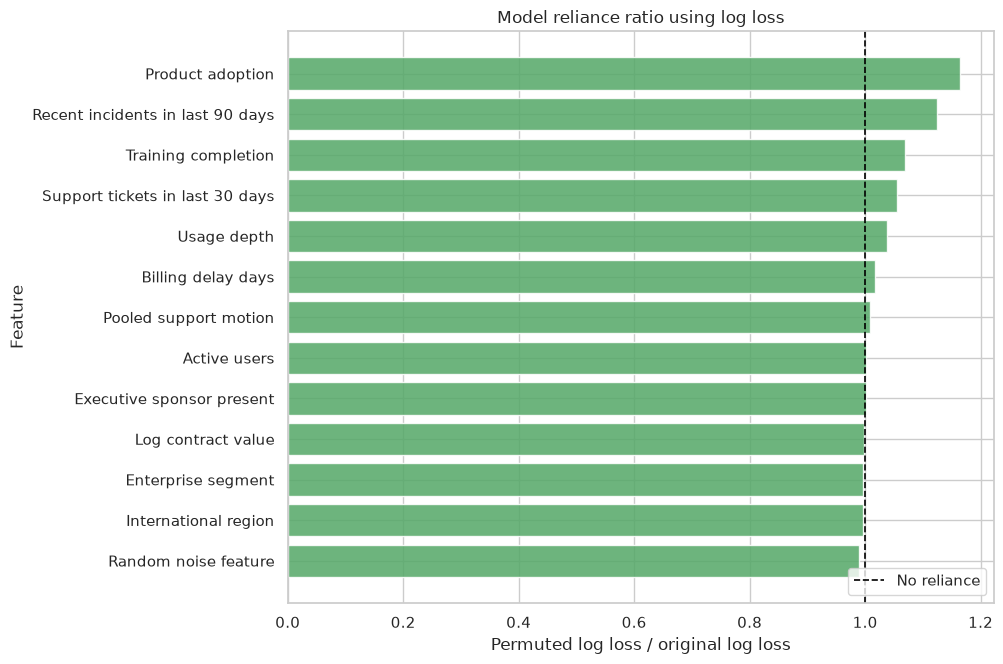

In [8]:
# Section focus: 6. Loss-Ratio Model Reliance.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def repeated_model_reliance_loss(model, X, y, features, metric='log_loss', n_repeats=35, seed=2033):
    """Carry out the repeated model reliance loss step used in the 07. Permutation Importance and Model Reliance workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    y : object
        Observed target values used for fitting or evaluation.
    features : object
        Feature column names or feature matrix used by the model.
    metric : object
        Metric name or metric value used to score model or decision behavior.
    n_repeats : object
        Count or size setting for the repeated model reliance loss calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    baseline = evaluate_loss(model, X, y, metric=metric)
    rows = []
    X_base = X.reset_index(drop=True)

    for feature in features:
        for repeat in range(n_repeats):
            X_perm = X_base.copy()
            X_perm[feature] = rng.permutation(X_perm[feature].to_numpy())
            permuted_loss = evaluate_loss(model, X_perm, y, metric=metric)
            rows.append(
                {
                    'feature': feature,
                    'feature_label': FEATURE_LABELS[feature],
                    'repeat': repeat,
                    'metric': metric,
                    'baseline_loss': baseline,
                    'permuted_loss': permuted_loss,
                    'loss_increase': permuted_loss - baseline,
                    'model_reliance_ratio': permuted_loss / baseline,
                }
            )
    return pd.DataFrame(rows)

mr_logloss_gbm = repeated_model_reliance_loss(
    gbm_model,
    X_test,
    y_test,
    FEATURES,
    metric='log_loss',
    n_repeats=28,
    seed=2033,
)
mr_summary = (
    mr_logloss_gbm.groupby(['feature', 'feature_label'], as_index=False)
    .agg(
        mean_loss_increase=('loss_increase', 'mean'),
        mean_model_reliance_ratio=('model_reliance_ratio', 'mean'),
        p05_ratio=('model_reliance_ratio', lambda x: np.quantile(x, 0.05)),
        p95_ratio=('model_reliance_ratio', lambda x: np.quantile(x, 0.95)),
    )
    .sort_values('mean_model_reliance_ratio', ascending=False)
)
smart_display(mr_summary.round(4))

fig, ax = plt.subplots(figsize=(10.2, 6.8))
plot_mr = mr_summary.sort_values('mean_model_reliance_ratio', ascending=True)
ax.barh(plot_mr['feature_label'], plot_mr['mean_model_reliance_ratio'], color='#55a868', alpha=0.86)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='No reliance')
ax.set_title('Model reliance ratio using log loss')
ax.set_xlabel('Permuted log loss / original log loss')
ax.set_ylabel('Feature')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


Use the explanation as a stress test of the model narrative. In Loss-Ratio Model Reliance, the displayed reasons should make sense with the data-generating story and the operating decision. When explanation views disagree, the communication should become more careful.


### Discussion of Loss-Ratio Reliance

The ratio framing makes the baseline explicit. Values near one mean the log loss barely changes when the feature is disrupted. Larger values mean the model's probability predictions rely more heavily on that feature.

This may not produce exactly the same ranking as AUC-drop importance because log loss penalizes probability quality alongside ranking.


## 7. Correlated Features: Split Reliance And Masking

When two features carry similar information, permuting one may not damage performance much because the other remains intact. This can make both individual features look less important than the underlying construct.

For a group $G$ of features, grouped permutation disrupts all columns in the group together:

$$
I_G^{score}
= S(\hat f;D) - S(\hat f;D_G^{\pi}),
$$

where all features in $G$ are permuted jointly. Joint permutation preserves the within-group row alignment after shuffling the group block, but breaks the group as a whole from the outcome and other features.

This is often closer to how business teams think: maturity, support burden, commercial risk, and account scale are constructs rather than isolated columns.


In [9]:
# Section focus: 7. Correlated Features: Split Reliance And Masking.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

FEATURE_GROUPS = {
    'Maturity signals': ['training_completion', 'product_adoption', 'usage_depth', 'active_users'],
    'Support burden': ['support_tickets_30d', 'recent_incidents_90d', 'pooled_support_motion'],
    'Commercial context': ['billing_delay_days', 'contract_value_log', 'executive_sponsor'],
    'Account context': ['enterprise_segment', 'international_region'],
    'Noise check': ['random_noise_feature'],
}


def repeated_group_permutation_importance(model, X, y, groups, metric='roc_auc', n_repeats=45, seed=2034):
    """Carry out the repeated group permutation importance step used in the 07. Permutation Importance and Model Reliance workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    y : object
        Observed target values used for fitting or evaluation.
    groups : object
        The groups setting that controls the repeated group permutation importance calculation in this notebook.
    metric : object
        Metric name or metric value used to score model or decision behavior.
    n_repeats : object
        Count or size setting for the repeated group permutation importance calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    baseline = evaluate_score(model, X, y, metric=metric)
    X_base = X.reset_index(drop=True)
    rows = []

    for group_name, columns in groups.items():
        columns = list(columns)
        for repeat in range(n_repeats):
            X_perm = X_base.copy()
            shuffled_index = rng.permutation(len(X_perm))
            X_perm.loc[:, columns] = X_perm.loc[shuffled_index, columns].to_numpy()
            permuted_score = evaluate_score(model, X_perm, y, metric=metric)
            rows.append(
                {
                    'group': group_name,
                    'features': ', '.join(columns),
                    'repeat': repeat,
                    'baseline_score': baseline,
                    'permuted_score': permuted_score,
                    'score_drop': baseline - permuted_score,
                }
            )
    return pd.DataFrame(rows)

group_importance = repeated_group_permutation_importance(gbm_model, X_test, y_test, FEATURE_GROUPS, metric='roc_auc', n_repeats=32)
group_summary = (
    group_importance.groupby(['group', 'features'], as_index=False)
    .agg(
        mean_auc_drop=('score_drop', 'mean'),
        sd_auc_drop=('score_drop', 'std'),
        p05=('score_drop', lambda x: np.quantile(x, 0.05)),
        p95=('score_drop', lambda x: np.quantile(x, 0.95)),
    )
    .sort_values('mean_auc_drop', ascending=False)
)
smart_display(group_summary.round(4))

single_vs_group = pd.DataFrame(
    [
        {
            'construct': group_name,
            'sum_of_single_feature_auc_drops': importance_auc_summary.loc[importance_auc_summary['feature'].isin(cols), 'mean_score_drop'].sum(),
            'grouped_auc_drop': group_summary.loc[group_summary['group'].eq(group_name), 'mean_auc_drop'].iloc[0],
        }
        for group_name, cols in FEATURE_GROUPS.items()
    ]
)
single_vs_group['group_minus_sum'] = single_vs_group['grouped_auc_drop'] - single_vs_group['sum_of_single_feature_auc_drops']
smart_display(single_vs_group.round(4))


,group,features,mean_auc_drop,sd_auc_drop,p05,p95
2,Maturity signals,"training_completion, product_adoption, usage_depth, active_users",0.155200,0.019500,0.122000,0.185100
4,Support burden,"support_tickets_30d, recent_incidents_90d, pooled_support_motion",0.087100,0.010000,0.073500,0.104500
1,Commercial context,"billing_delay_days, contract_value_log, executive_sponsor",0.011800,0.006500,0.001700,0.020400
0,Account context,"enterprise_segment, international_region",-0.001000,0.001900,-0.004000,0.000900
3,Noise check,random_noise_feature,-0.005400,0.002900,-0.010700,-0.001500


,construct,sum_of_single_feature_auc_drops,grouped_auc_drop,group_minus_sum
0,Maturity signals,0.092100,0.155200,0.063100
1,Support burden,0.067000,0.087100,0.020100
2,Commercial context,0.005700,0.011800,0.006100
3,Account context,-0.000400,-0.001000,-0.000600
4,Noise check,-0.004200,-0.005400,-0.001200


Use the explanation as a stress test of the model narrative. In Correlated Features: Split Reliance And Masking, the displayed reasons should make sense with the data-generating story and the operating decision. Method-level disagreement is a reason to review the case before using the explanation operationally.


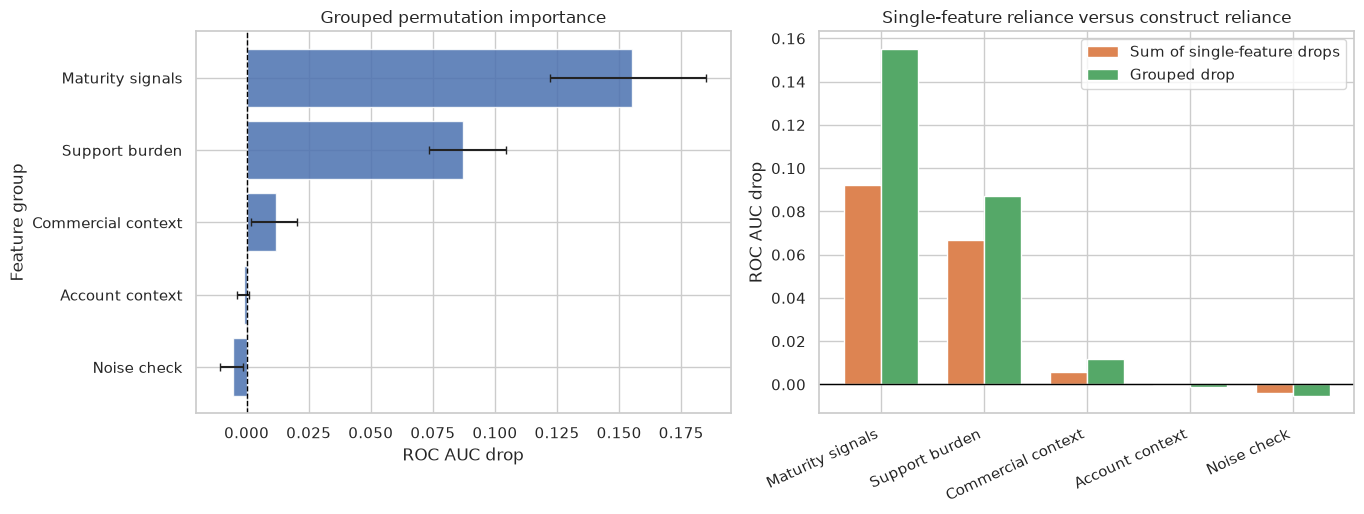

In [10]:
# Section focus: 7. Correlated Features: Split Reliance And Masking.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.3))

plot_group = group_summary.sort_values('mean_auc_drop', ascending=True)
axes[0].barh(plot_group['group'], plot_group['mean_auc_drop'], color='#4c72b0', alpha=0.86)
axes[0].errorbar(
    x=plot_group['mean_auc_drop'],
    y=np.arange(len(plot_group)),
    xerr=[plot_group['mean_auc_drop'] - plot_group['p05'], plot_group['p95'] - plot_group['mean_auc_drop']],
    fmt='none',
    ecolor='#222222',
    capsize=3,
)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Grouped permutation importance')
axes[0].set_xlabel('ROC AUC drop')
axes[0].set_ylabel('Feature group')

single_vs_group_plot = single_vs_group.sort_values('grouped_auc_drop', ascending=False).copy()
x = np.arange(len(single_vs_group_plot))
width = 0.36
axes[1].bar(x - width / 2, single_vs_group_plot['sum_of_single_feature_auc_drops'], width, label='Sum of single-feature drops', color='#dd8452')
axes[1].bar(x + width / 2, single_vs_group_plot['grouped_auc_drop'], width, label='Grouped drop', color='#55a868')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Single-feature reliance versus construct reliance')
axes[1].set_ylabel('ROC AUC drop')
axes[1].set_xticks(x)
axes[1].set_xticklabels(single_vs_group_plot['construct'], rotation=25, ha='right')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()


In Correlated Features: Split Reliance And Masking, pay attention to whether the explanation changes when the analyst changes plausible settings. Setting sensitivity belongs in the report because it changes the strength of the explanation.


### Discussion of Grouped Importance

Grouped importance is often the more useful decision diagnostic. The organization may not care whether the model uses `training_completion` or `product_adoption` separately; it may care whether the model depends on account maturity as a construct.

There is no universal rule that grouped importance must be larger than the sum of single-feature importances. Interactions, redundancy, and metric nonlinearities can make the relationship complicated. The point is conceptual: grouped permutation asks a different question, and often the more relevant one.


## 8. Conditional Or Stratified Permutation As A Correlation Diagnostic

Marginal permutation breaks the relationship between a feature and all other features. If the feature is correlated with other predictors, this may create unrealistic combinations, similar to the PDP issue from the previous notebook.

A pragmatic diagnostic is **stratified permutation**: permute a feature only within strata defined by correlated companion variables. This preserves some dependence structure and asks a more local question:

> Does this feature add predictive information beyond what is already captured by the stratification variables?

This is not a full implementation of conditional permutation importance, but it is a practical approximation for teaching and model review.


,feature,feature_label,strata,stratified_auc_drop,stratified_sd,marginal_auc_drop,marginal_minus_stratified
0,product_adoption,Product adoption,"training_completion, usage_depth",0.017900,0.005900,0.056200,0.038200
1,recent_incidents_90d,Recent incidents in last 90 days,"support_tickets_30d, pooled_support_motion",0.037600,0.004600,0.038400,0.000800
2,support_tickets_30d,Support tickets in last 30 days,"recent_incidents_90d, pooled_support_motion",0.007800,0.006500,0.022400,0.014600
3,training_completion,Training completion,"product_adoption, usage_depth",0.003800,0.004300,0.020400,0.016700


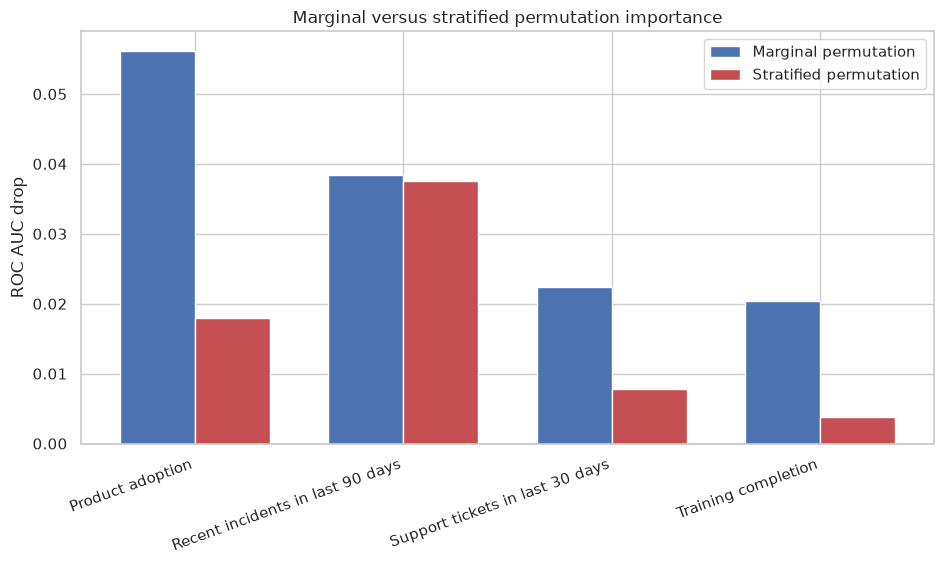

In [11]:
# Section focus: 8. Conditional Or Stratified Permutation As A Correlation Diagnostic.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def stratified_permutation_importance_score(model, X, y, feature, strata_columns, metric='roc_auc', n_repeats=45, n_bins=5, seed=2035):
    """Carry out the stratified permutation importance score step used in the 07. Permutation Importance and Model Reliance workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    y : object
        Observed target values used for fitting or evaluation.
    feature : object
        Column or variable name used to select information from the input table.
    strata_columns : object
        Column or variable name used to select information from the input table.
    metric : object
        Metric name or metric value used to score model or decision behavior.
    n_repeats : object
        Count or size setting for the stratified permutation importance score calculation.
    n_bins : object
        Count or size setting for the stratified permutation importance score calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    baseline = evaluate_score(model, X, y, metric=metric)
    X_base = X.reset_index(drop=True)
    strata_df = pd.DataFrame(index=X_base.index)

    for column in strata_columns:
        values = X_base[column]
        if values.nunique() <= n_bins:
            strata_df[column] = values.astype(str)
        else:
            strata_df[column] = pd.qcut(values.rank(method='first'), q=n_bins, labels=False, duplicates='drop').astype(str)

    strata_key = strata_df.astype(str).agg('|'.join, axis=1)
    groups = [group_index.to_numpy() for _, group_index in pd.Series(X_base.index).groupby(strata_key)]

    rows = []
    for repeat in range(n_repeats):
        X_perm = X_base.copy()
        permuted_values = X_perm[feature].to_numpy().copy()
        for idx in groups:
            if len(idx) > 1:
                permuted_values[idx] = rng.permutation(permuted_values[idx])
        X_perm[feature] = permuted_values
        permuted_score = evaluate_score(model, X_perm, y, metric=metric)
        rows.append(
            {
                'feature': feature,
                'feature_label': FEATURE_LABELS[feature],
                'strata': ', '.join(strata_columns),
                'repeat': repeat,
                'score_drop': baseline - permuted_score,
                'permuted_score': permuted_score,
            }
        )
    return pd.DataFrame(rows)

conditional_specs = [
    {'feature': 'training_completion', 'strata_columns': ['product_adoption', 'usage_depth']},
    {'feature': 'product_adoption', 'strata_columns': ['training_completion', 'usage_depth']},
    {'feature': 'support_tickets_30d', 'strata_columns': ['recent_incidents_90d', 'pooled_support_motion']},
    {'feature': 'recent_incidents_90d', 'strata_columns': ['support_tickets_30d', 'pooled_support_motion']},
]

stratified_rows = []
for spec in conditional_specs:
    stratified_rows.append(
        stratified_permutation_importance_score(
            gbm_model,
            X_test,
            y_test,
            spec['feature'],
            spec['strata_columns'],
            metric='roc_auc',
            n_repeats=28,
            n_bins=5,
            seed=2035,
        )
    )
stratified_importance = pd.concat(stratified_rows, ignore_index=True)
stratified_summary = (
    stratified_importance.groupby(['feature', 'feature_label', 'strata'], as_index=False)
    .agg(stratified_auc_drop=('score_drop', 'mean'), stratified_sd=('score_drop', 'std'))
)

marginal_selected = importance_auc_summary.loc[
    importance_auc_summary['feature'].isin(stratified_summary['feature']),
    ['feature', 'mean_score_drop'],
].rename(columns={'mean_score_drop': 'marginal_auc_drop'})
conditional_comparison = stratified_summary.merge(marginal_selected, on='feature', how='left')
conditional_comparison['marginal_minus_stratified'] = conditional_comparison['marginal_auc_drop'] - conditional_comparison['stratified_auc_drop']
conditional_comparison = conditional_comparison.sort_values('marginal_auc_drop', ascending=False)
smart_display(conditional_comparison.round(4))

fig, ax = plt.subplots(figsize=(9.6, 5.8))
plot_cond = conditional_comparison.sort_values('marginal_auc_drop', ascending=False)
x = np.arange(len(plot_cond))
width = 0.36
ax.bar(x - width / 2, plot_cond['marginal_auc_drop'], width, label='Marginal permutation', color='#4c72b0')
ax.bar(x + width / 2, plot_cond['stratified_auc_drop'], width, label='Stratified permutation', color='#c44e52')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Marginal versus stratified permutation importance')
ax.set_ylabel('ROC AUC drop')
ax.set_xticks(x)
ax.set_xticklabels(plot_cond['feature_label'], rotation=20, ha='right')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


The explanation result should be compared with the decision story. In Conditional Or Stratified Permutation As A Correlation Diagnostic, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. Weak explanations push the hard work back onto the reviewer.


### Discussion of Stratified Permutation

When stratified importance is much smaller than marginal importance, the feature may be important mostly as part of a correlated bundle. That does not make it useless. It means the model can recover some of the lost information from related variables.

For governance, this is a gift: it tells us that feature reliance should be reviewed at two levels.

1. **Raw feature reliance**: does the model use this column?
2. **Construct reliance**: does the model use the broader operational concept?

Many stakeholder conversations become clearer when they shift from raw columns to constructs.


## 9. Model-Specific Reliance

The same dataset can support multiple good models with different reliance profiles. This is related to the broader Rashomon-set idea: many models may perform similarly while using different internal logic.

Here we compute AUC-drop permutation importance for all three fitted models and compare rankings.


model,feature_label,Gradient boosting,Logistic regression,Random forest
7,Product adoption,0.051700,0.022200,0.037500
9,Recent incidents in last 90 days,0.039100,0.051500,0.035100
11,Training completion,0.021800,0.011400,0.013900
10,Support tickets in last 30 days,0.020500,0.021500,0.014500
12,Usage depth,0.012400,0.004900,0.002600
1,Billing delay days,0.008600,0.010500,0.005300
6,Pooled support motion,0.006600,0.002600,0.003400
5,Log contract value,0.000300,0.002800,0.000800
0,Active users,0.000200,0.001000,-0.000600
3,Executive sponsor present,-0.000000,0.006100,0.000800


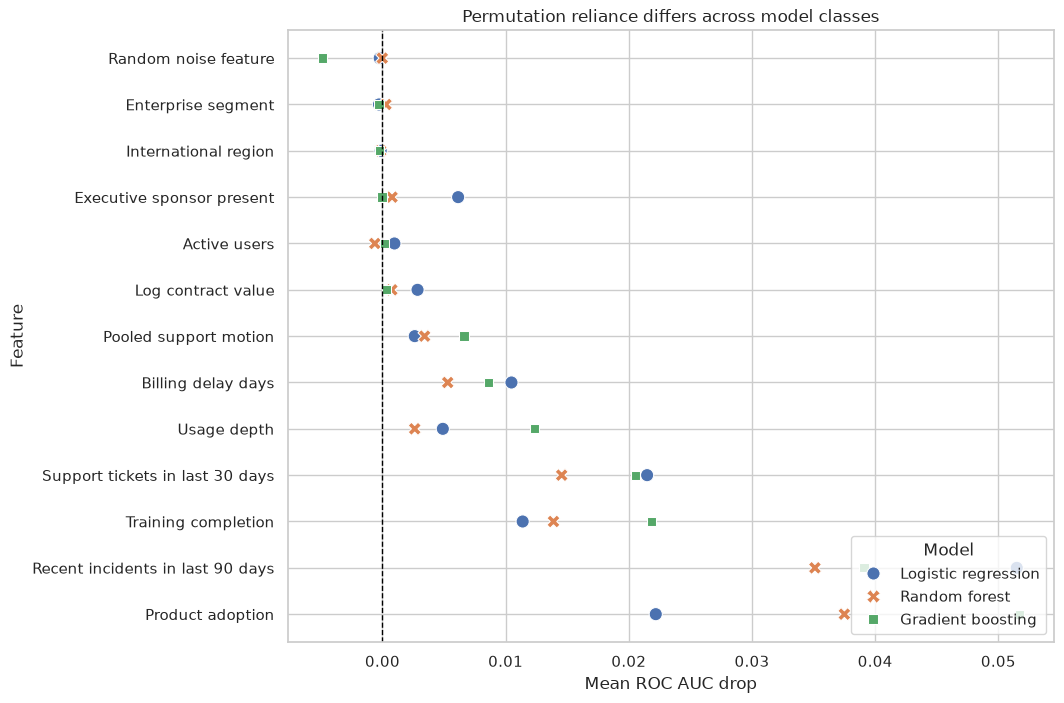

In [12]:
# Section focus: 9. Model-Specific Reliance.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

model_importance_rows = []
for model_name, model in models.items():
    imp = repeated_permutation_importance_score(
        model,
        X_test,
        y_test,
        FEATURES,
        metric='roc_auc',
        n_repeats=22,
        seed=2040 + len(model_name),
    )
    summary_model = summarize_score_importance(imp)
    summary_model['model'] = model_name
    model_importance_rows.append(summary_model)

model_importance = pd.concat(model_importance_rows, ignore_index=True)
model_importance['rank_within_model'] = model_importance.groupby('model')['mean_score_drop'].rank(ascending=False, method='min').astype(int)

importance_wide = (
    model_importance.pivot_table(index='feature_label', columns='model', values='mean_score_drop')
    .reset_index()
    .sort_values('Gradient boosting', ascending=False)
)
smart_display(importance_wide.round(4))

fig, ax = plt.subplots(figsize=(10.8, 7.2))
plot_model_imp = model_importance.copy()
plot_model_imp['feature_label'] = pd.Categorical(
    plot_model_imp['feature_label'],
    categories=importance_wide['feature_label'][::-1],
    ordered=True,
)
sns.scatterplot(
    data=plot_model_imp,
    x='mean_score_drop',
    y='feature_label',
    hue='model',
    style='model',
    s=90,
    ax=ax,
)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Permutation reliance differs across model classes')
ax.set_xlabel('Mean ROC AUC drop')
ax.set_ylabel('Feature')
ax.legend(title='Model', loc='lower right')
plt.tight_layout()
plt.show()


For Model-Specific Reliance, the explanation earns trust through stability and reviewability, not through a polished chart alone.


### Discussion of Model-Specific Reliance

Different models can learn different shortcuts and substitutions. A logistic model may rely more on a smooth maturity signal, while a tree ensemble may rely more on threshold-like burden variables or interactions.

This matters for audits. If two equally accurate models rely on very different features, the analyst should not present one feature-importance ranking as if it were the truth. It is the reliance profile of one fitted model.


## 10. Built-In Scikit-Learn Permutation Importance

Scikit-learn includes a convenient implementation of permutation importance. The custom implementation above was useful because it made the estimand explicit. The library implementation is what you might use in routine production analysis.

The same cautions apply: choose the metric deliberately, compute on held-out data, repeat permutations, include a null feature when possible, and inspect correlated feature groups.


In [13]:
# Section focus: 10. Built-In Scikit-Learn Permutation Importance.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

sklearn_result = permutation_importance(
    gbm_model,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=22,
    random_state=2036,
    n_jobs=1,
)

sklearn_importance = pd.DataFrame(
    {
        'feature': FEATURES,
        'feature_label': [FEATURE_LABELS[f] for f in FEATURES],
        'sklearn_mean_auc_drop': sklearn_result.importances_mean,
        'sklearn_sd': sklearn_result.importances_std,
    }
).sort_values('sklearn_mean_auc_drop', ascending=False)

comparison_to_custom = sklearn_importance.merge(
    importance_auc_summary[['feature', 'mean_score_drop']].rename(columns={'mean_score_drop': 'custom_mean_auc_drop'}),
    on='feature',
    how='left',
)
comparison_to_custom['absolute_difference'] = (
    comparison_to_custom['sklearn_mean_auc_drop'] - comparison_to_custom['custom_mean_auc_drop']
).abs()
smart_display(comparison_to_custom.round(4))


,feature,feature_label,sklearn_mean_auc_drop,sklearn_sd,custom_mean_auc_drop,absolute_difference
0,product_adoption,Product adoption,0.053800,0.009800,0.056200,0.002300
1,recent_incidents_90d,Recent incidents in last 90 days,0.037400,0.005800,0.038400,0.001000
2,support_tickets_30d,Support tickets in last 30 days,0.022700,0.010000,0.022400,0.000200
3,training_completion,Training completion,0.019800,0.007700,0.020400,0.000600
4,usage_depth,Usage depth,0.018700,0.006200,0.016400,0.002300
5,billing_delay_days,Billing delay days,0.008100,0.004400,0.006000,0.002100
6,pooled_support_motion,Pooled support motion,0.006900,0.003200,0.006200,0.000700
7,executive_sponsor,Executive sponsor present,0.000300,0.001000,0.000300,0.000000
8,active_users,Active users,-0.000000,0.005100,-0.000800,0.000800
9,enterprise_segment,Enterprise segment,-0.000300,0.000600,-0.000100,0.000200


For Built-In Scikit-Learn Permutation Importance, read the explanation as something a stakeholder may challenge. Stability, clarity, and sensitivity all matter.


## 11. Decision-Science Interpretation Checklist

Permutation importance is useful when it is connected to the decision context.

| Question | Good interpretation | Bad interpretation |
|---|---|---|
| What does a high value mean? | The fitted model's held-out performance depends on this feature | This feature is causally important |
| What does a low value mean? | The model can perform similarly after this feature is disrupted | This feature is irrelevant to the business |
| What if features are correlated? | Importance may be split, masked, or transferred | The smaller individual score proves the feature is unimportant |
| What if a proxy is important? | The model may rely on a sensitive or operationally fragile signal | The proxy should automatically be used for decisions |
| What if rankings differ across models? | Different good models use different prediction strategies | One ranking must be objectively correct |
| What should be reported? | Metric, dataset, repetitions, uncertainty, correlated groups, and null checks | A single ranked list without context |


In [14]:
# Section focus: 11. Decision-Science Interpretation Checklist.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

reliance_audit = pd.DataFrame(
    [
        {
            'audit_question': 'Does the model rely on obvious noise?',
            'diagnostic': 'Random noise feature should have near-zero importance',
            'finding': 'Noise feature is near the bottom of the ranking',
            'action': 'Keep as a sanity check in future examples and tests',
        },
        {
            'audit_question': 'Are maturity signals individually or jointly important?',
            'diagnostic': 'Compare single-feature and grouped permutation importance',
            'finding': 'Maturity construct is stronger than any one raw maturity column alone',
            'action': 'Explain reliance at construct level, not only raw-column level',
        },
        {
            'audit_question': 'Do correlated features mask each other?',
            'diagnostic': 'Compare marginal and stratified permutation drops',
            'finding': 'Some marginal reliance shrinks after preserving correlated companions',
            'action': 'Treat correlated predictors as substitutable evidence, not isolated causes',
        },
        {
            'audit_question': 'Is reliance stable across model classes?',
            'diagnostic': 'Compare logistic, random forest, and gradient boosting reliance profiles',
            'finding': 'Reliance rankings differ across models with reasonable performance',
            'action': 'Do not present one ranking as model-independent truth',
        },
    ]
)
smart_display(reliance_audit)


,audit_question,diagnostic,finding,action
0,Does the model rely on obvious noise?,Random noise feature should have near-zero importance,Noise feature is near the bottom of the ranking,Keep as a sanity check in future examples and tests
1,Are maturity signals individually or jointly important?,Compare single-feature and grouped permutation importance,Maturity construct is stronger than any one raw maturity column alone,"Explain reliance at construct level, not only raw-column level"
2,Do correlated features mask each other?,Compare marginal and stratified permutation drops,Some marginal reliance shrinks after preserving correlated companions,"Treat correlated predictors as substitutable evidence, not isolated causes"
3,Is reliance stable across model classes?,"Compare logistic, random forest, and gradient boosting reliance profiles",Reliance rankings differ across models with reasonable performance,Do not present one ranking as model-independent truth


The explanation result should be compared with the decision story. In Decision-Science Interpretation Checklist, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. A clear explanation lowers ambiguity for the stakeholder and makes review more focused.


## 12. Key Takeaways

- Permutation importance measures performance deterioration after disrupting feature information.
- Model reliance can be expressed as a loss increase or as a perturbed-loss/original-loss ratio.
- Importance is tied to a fitted model, evaluation metric, held-out dataset, and permutation design.
- Correlated features can mask each other, split importance, or make marginal permutations unrealistic.
- Grouped permutation is often better aligned with business constructs than single-column permutation.
- Stratified permutation can help ask whether a feature adds information beyond correlated companions.
- Negative or tiny importance values can occur from finite-sample noise or redundant information.
- Feature importance is not causality, actionability, fairness, or business value.
- A professional report should include the metric, baseline performance, repeated uncertainty, correlated feature checks, and a clear noncausal interpretation.


## References

- Altmann, A., Toloşi, L., Sander, O., & Lengauer, T. (2010). *Permutation importance: a corrected feature importance measure*. *Bioinformatics, 26*(10), 1340-1347. [https://doi.org/10.1093/bioinformatics/btq134](https://doi.org/10.1093/bioinformatics/btq134)
- Breiman, L. (2001). *Random Forests*. *Machine Learning, 45*(1), 5-32. [https://doi.org/10.1023/A:1010933404324](https://doi.org/10.1023/A:1010933404324)
- Fisher, A., Rudin, C., & Dominici, F. (2018). *All Models are Wrong, but Many are Useful: Learning a Variable's Importance by Studying an Entire Class of Prediction Models Simultaneously*. arXiv. [https://doi.org/10.48550/arXiv.1801.01489](https://doi.org/10.48550/arXiv.1801.01489)
- Debeer, D., & Strobl, C. (2020). *Conditional permutation importance revisited*. *BMC Bioinformatics, 21*, 307. [https://doi.org/10.1186/s12859-020-03622-2](https://doi.org/10.1186/s12859-020-03622-2)
- scikit-learn developers. *Permutation feature importance*. [https://scikit-learn.org/stable/modules/permutation_importance.html](https://scikit-learn.org/stable/modules/permutation_importance.html)
